In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## Image segmentation with SAM 3

This notebook demonstrates how to use SAM 3 for image segmentation with text or visual prompts. It covers the following capabilities:

- **Text prompts**: Using natural language descriptions to segment objects (e.g., "person", "face")
- **Box prompts**: Using bounding boxes as exemplar visual prompts

# <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam3/blob/main/notebooks/sam3_image_predictor_example.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>

In [1]:
using_colab = True

In [2]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True
  Cloning https://github.com/facebookresearch/sam3.git to /tmp/pip-req-build-tjttku7c
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam3.git /tmp/pip-req-build-tjttku7c
  Resolved https://github.com/facebookresearch/sam3.git to commit f6e51f59500a87c576c2df2323ce56b9fd7a12de
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. Th

In [3]:
%pip install decord einops

In [4]:
%pip install "numpy>=2" scipy scikit-image decord einops


  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sam3 0.1.0 requires numpy<2,>=1.26, but you have numpy 2.4.3 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompatible.


In [5]:
%pip install "scikit-image<0.25"

In [6]:
%pip install -q git+https://github.com/facebookresearch/sam3.git
%pip install -q "scikit-image<0.25" decord einops "numpy>=2"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 r

In [7]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7a253cfa72e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


In [8]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# Build Model

### Verificaciones

In [ ]:
import torch
print(f"GPU: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


GPU: True
Device: Tesla T4


In [ ]:
import psutil
print(f"RAM disponible: {psutil.virtual_memory().available / 1e9:.1f} GB")


RAM disponible: 12.2 GB


### Build

In [9]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [10]:
%pip install psutil
import psutil


In [11]:
import torch
import os
print("Antes de cargar modelo")
print(f"RAM: {psutil.virtual_memory().available / 1e9:.1f} GB")
print(f"VRAM: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB libre")

bpe_path = os.path.join(os.path.dirname(sam3.__file__), "assets", "bpe_simple_vocab_16e6.txt.gz")
model = build_sam3_image_model(bpe_path=bpe_path, device="cuda")

print("Modelo cargado exitosamente")


Antes de cargar modelo
RAM: 11.7 GB
VRAM: 15.5 GB libre
Modelo cargado exitosamente


In [ ]:
import os
sam3_dir = os.path.dirname(sam3.__file__)
for root, dirs, files in os.walk(os.path.join(sam3_dir, "assets")):
    for f in files:
        print(os.path.join(root, f))


/usr/local/lib/python3.12/dist-packages/sam3/assets/bpe_simple_vocab_16e6.txt.gz


In [12]:
from google.colab import drive
drive.mount('/content/drive')
# Luego sube la imagen a tu Drive y usa la ruta:
# image_path = "/content/drive/MyDrive/tu_imagen.jpeg"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
image_path = "/content/drive/MyDrive/LGH020002 - frame at 1m18s.jpg.jpeg"

In [ ]:
import os
print(os.path.exists(image_path))
print(os.listdir("/content/drive/MyDrive/")[:20])  # ver primeros 20 archivos en Drive


True
['LGH020002 - frame at 1m18s.jpg.jpeg', 'eva carpeta', 'Classroom', 'Formulario sin título.gform', 'JONATHAN', 'Untitled.pdf', 'FB_IMG_1603667239109.jpg', '1606257510603.jpg', '1606257557439.jpg', 'Autoaprendizaje (respuestas).gsheet', 'Lista de tareas (1).gsheet', 'Planificación de turnos de empleados .gsheet', 'Asistencia.gsheet', 'REGISTRO SEMANAL DE ANOTACIÓN DE MINIJUEGOS.gsheet', 'Documento sin título (7).gdoc', 'maicra.zip', 'download.pdf', 'download (1).gdoc', 'download.gdoc', 'download (2)']


In [13]:
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.5)
inference_state = processor.set_image(image)

NameError: name 'image_path' is not defined

# Text prompt

In [14]:
image_paths = [
    "/content/drive/MyDrive/LGH020002 - frame at 1m18s.jpg.jpeg",
    "/content/drive/MyDrive/LGH020002 - frame at 3m11s.jpg.jpeg",
    "/content/drive/MyDrive/LGH020002 - frame at 5m34s.jpg.jpeg",
    "/content/drive/MyDrive/LGH020002 - frame at 9m36s.jpg.jpeg",
    "/content/drive/MyDrive/LGH020002 - frame at 10m53s.jpg.jpeg",
]


In [17]:
from sam3.visualization_utils import COLORS, plot_mask, plot_bbox

In [18]:
def plot_results_no_labels(img, results):
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    nb_objects = len(results["scores"])
    print(f"found {nb_objects} object(s)")
    for i in range(nb_objects):
        color = COLORS[i % len(COLORS)]
        plot_mask(results["masks"][i].squeeze(0).cpu(), color=color)
        w, h = img.size
        plot_bbox(
            h, w,
            results["boxes"][i].cpu(),
            text="",
            box_format="XYXY",
            color=color,
            relative_coords=False,
        )


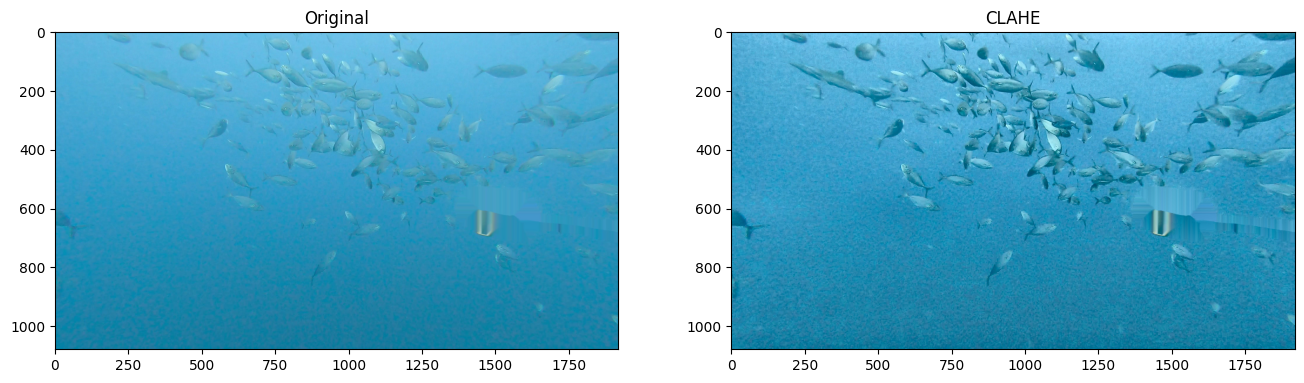

found 125 object(s)


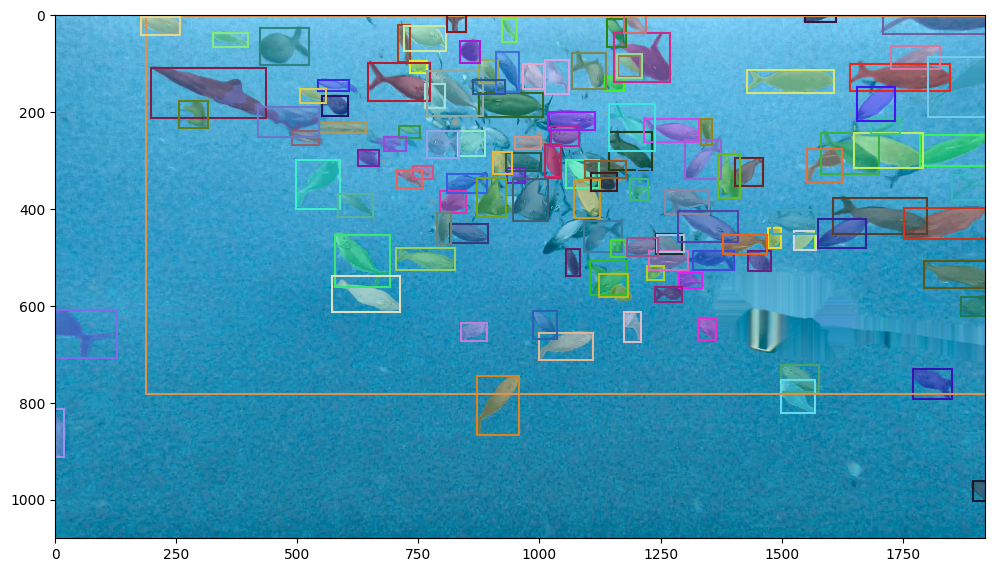

In [20]:
import cv2
import numpy as np
from PIL import Image

image_path = "/content/drive/MyDrive/LGH020002 - frame at 5m34s.jpg.jpeg"

# Mejorar contraste con CLAHE
img_cv = cv2.imread(image_path)
lab = cv2.cvtColor(img_cv, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
cl = clahe.apply(l)
merged = cv2.merge((cl, a, b))
enhanced_img_cv = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
enhanced_image = Image.fromarray(enhanced_img_cv)

# Mostrar comparación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(Image.open(image_path))
axes[0].set_title("Original")
axes[1].imshow(enhanced_image)
axes[1].set_title("CLAHE")
plt.show()

# Probar SAM3 con imagen mejorada y threshold bajo
processor = Sam3Processor(model, confidence_threshold=0.2)
inference_state = processor.set_image(enhanced_image)
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="fish")
plot_results_no_labels(enhanced_image, inference_state)
plt.show()


In [24]:
import inspect
print(inspect.getsource(plot_results))


def plot_results(img, results):
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    nb_objects = len(results["scores"])
    print(f"found {nb_objects} object(s)")
    for i in range(nb_objects):
        color = COLORS[i % len(COLORS)]
        plot_mask(results["masks"][i].squeeze(0).cpu(), color=color)
        w, h = img.size
        prob = results["scores"][i].item()
        plot_bbox(
            h,
            w,
            results["boxes"][i].cpu(),
            text=f"(id={i}, {prob=:.2f})",
            box_format="XYXY",
            color=color,
            relative_coords=False,
        )



found 67 object(s)


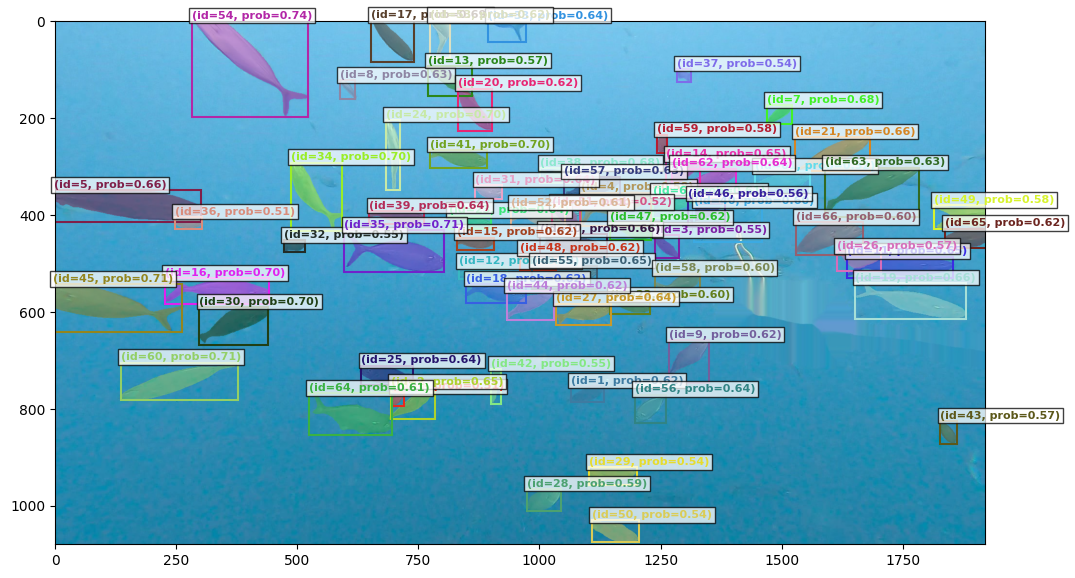

found 31 object(s)


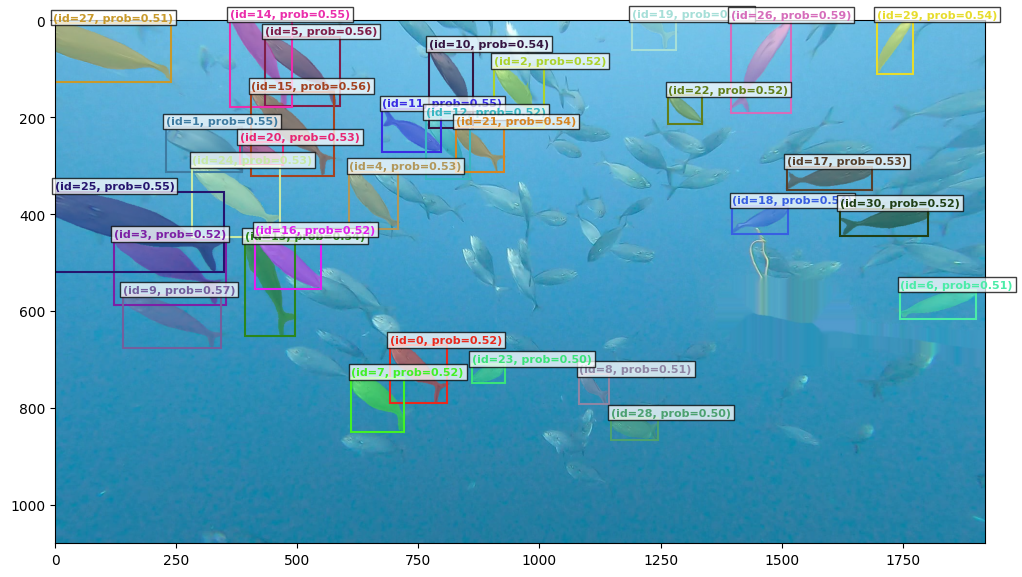

found 4 object(s)


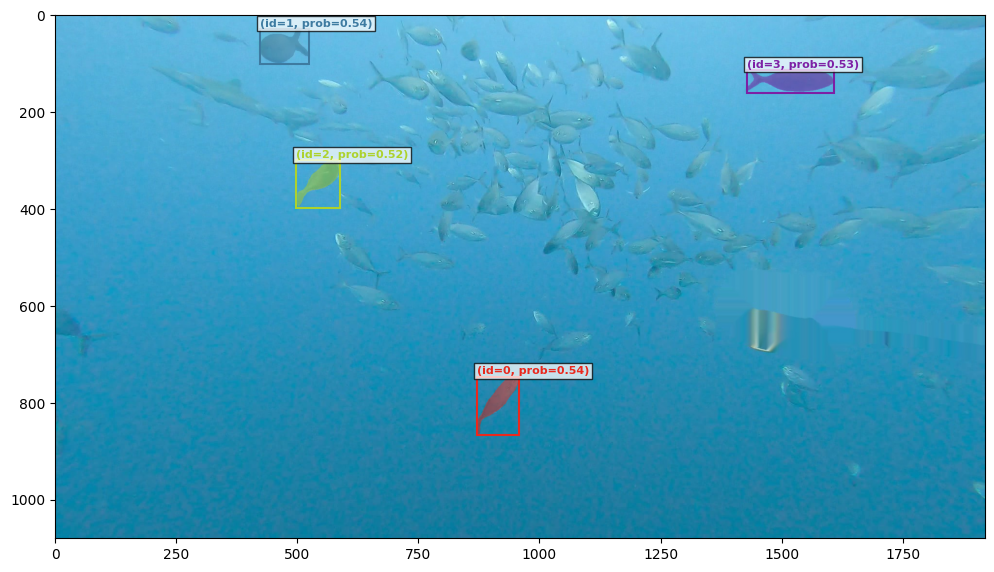

found 66 object(s)


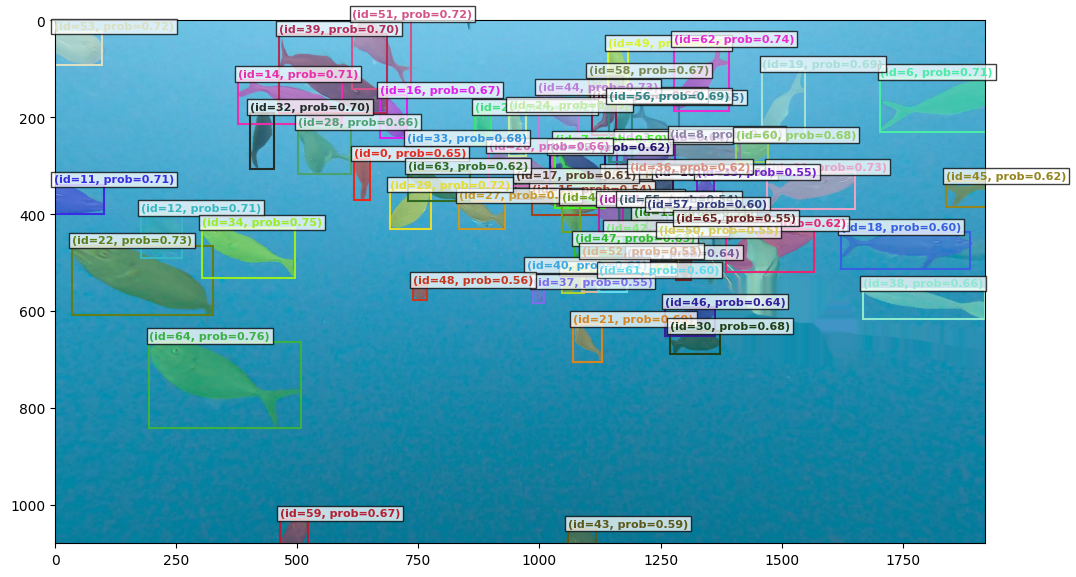

found 73 object(s)


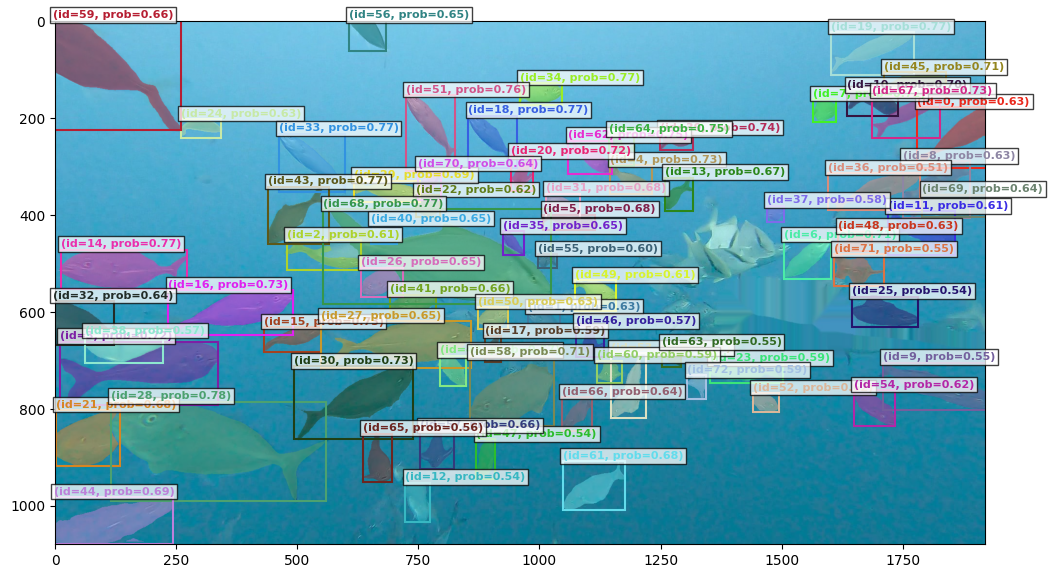

In [21]:

import gc
import torch

for image_path in image_paths:
    image = Image.open(image_path)
    processor = Sam3Processor(model, confidence_threshold=0.5)
    inference_state = processor.set_image(image)

    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_text_prompt(state=inference_state, prompt="fish")

    img0 = Image.open(image_path)
    plot_results(img0, inference_state)
    plt.show()

    # Liberar memoria
    del inference_state, processor, image, img0
    gc.collect()
    torch.cuda.empty_cache()


found 67 object(s)


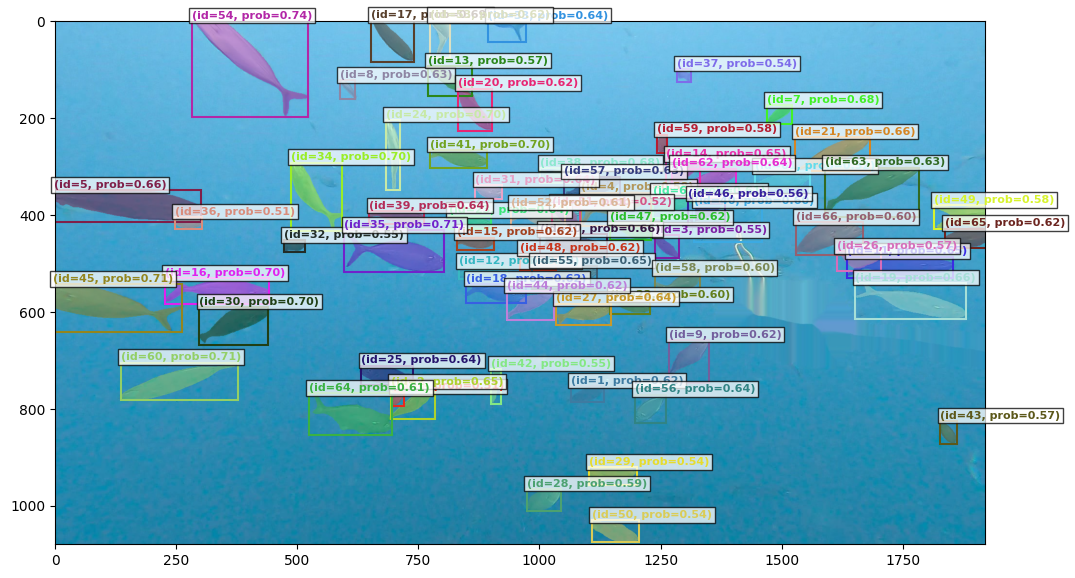

In [28]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="fish")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

### Visual prompt: a single bounding box

Normalized box input: [0.2786458432674408, 0.43518519401550293, 0.0572916679084301, 0.3333333432674408]


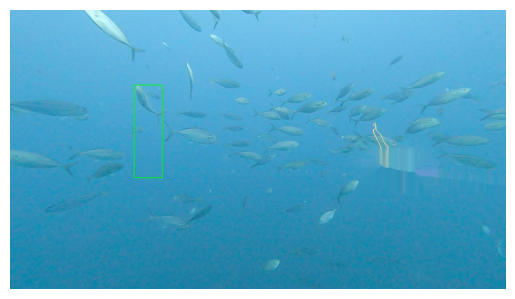

In [29]:
# Here the box is in  (x,y,w,h) format, where (x,y) is the top left corner.
box_input_xywh = torch.tensor([480.0, 290.0, 110.0, 360.0]).view(-1, 4)
box_input_cxcywh = box_xywh_to_cxcywh(box_input_xywh)

norm_box_cxcywh = normalize_bbox(box_input_cxcywh, width, height).flatten().tolist()
print("Normalized box input:", norm_box_cxcywh)

processor.reset_all_prompts(inference_state)
inference_state = processor.add_geometric_prompt(
    state=inference_state, box=norm_box_cxcywh, label=True
)

img0 = Image.open(image_path)
image_with_box = draw_box_on_image(img0, box_input_xywh.flatten().tolist())
plt.imshow(image_with_box)
plt.axis("off")  # Hide the axis
plt.show()

found 56 object(s)


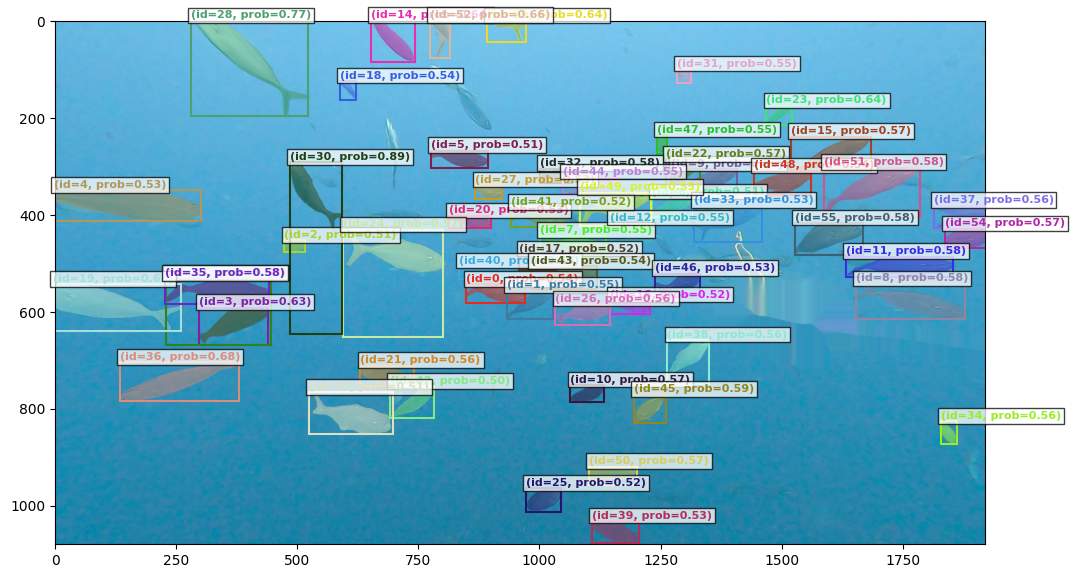

In [30]:
plot_results(img0, inference_state)

### Visual prompt: multi-box prompting (with positive and negative boxes)

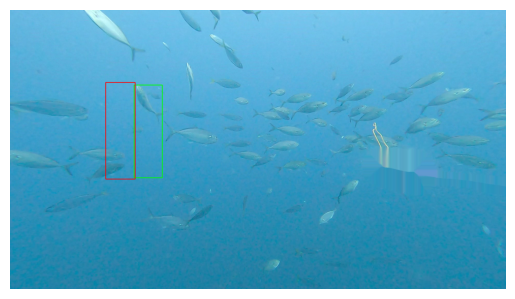

In [31]:
box_input_xywh = [[480.0, 290.0, 110.0, 360.0], [370.0, 280.0, 115.0, 375.0]]
box_input_cxcywh = box_xywh_to_cxcywh(torch.tensor(box_input_xywh).view(-1,4))
norm_boxes_cxcywh = normalize_bbox(box_input_cxcywh, width, height).tolist()

box_labels = [True, False]

processor.reset_all_prompts(inference_state)

for box, label in zip(norm_boxes_cxcywh, box_labels):
    inference_state = processor.add_geometric_prompt(
        state=inference_state, box=box, label=label
    )

img0 = Image.open(image_path)
image_with_box = img0
for i in range(len(box_input_xywh)):
    if box_labels[i] == 1:
        color = (0, 255, 0)
    else:
        color = (255, 0, 0)
    image_with_box = draw_box_on_image(image_with_box, box_input_xywh[i], color)
plt.imshow(image_with_box)
plt.axis("off")  # Hide the axis
plt.show()

found 15 object(s)


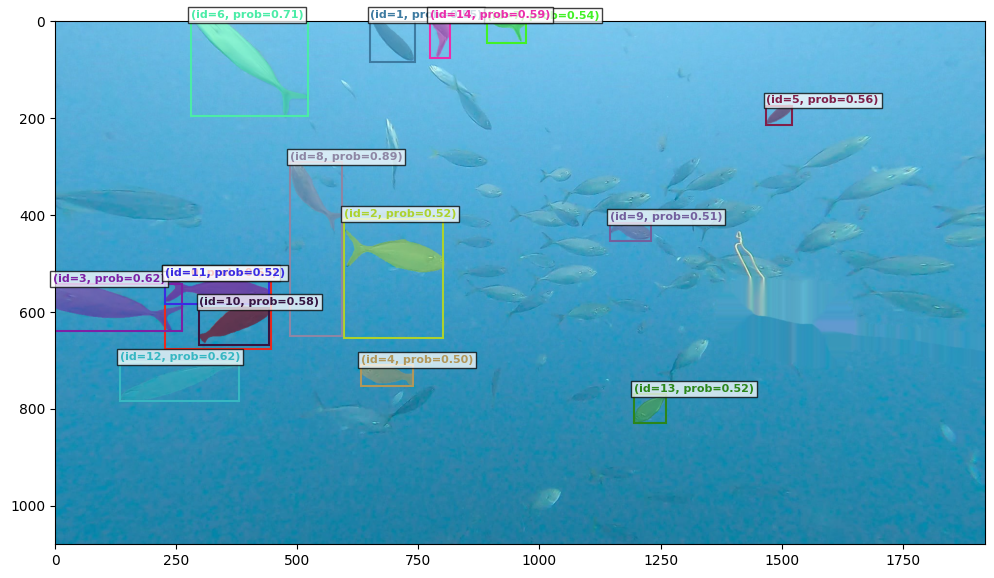

In [32]:
plot_results(img0, inference_state)